# 15 — Direct CNN Multiclass Baseline — Full Training Set

Baseline richiesta dal tutor: **stessa FCGR k=6, stesso backbone CNN V3, stesso full training set**, ma classificazione diretta a 12 classi.

Confronto controllato:
- Siamese: embedding L2 + Contrastive Loss + similarity ranking;
- Direct CNN: stessa rappresentazione 128D → `Linear(128,12)` → logits;
- training bilanciato con batch da 60 = 5 campioni per classe;
- loss: CrossEntropy;
- best checkpoint scelto su **validation Macro-F1**.

Durante il training non si applica Softmax esplicitamente: `CrossEntropyLoss` usa i logits. Softmax serve solo in evaluation/inference.


In [1]:
# ============================================================
# CELL 1 — IMPORTS + FIXED CONFIG
# ============================================================

from pathlib import Path
import random
import time
import copy
import math

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    Sampler
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "cnn_multiclass_fulltrain"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_manifest.tsv"
)

CLASS_MAPPING_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_class_mapping.tsv"
)

VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)

TEST_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_test_pair_pool.tsv"
)

FCGR_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / "fcgr_k6.npy"
)

FCGR_INDEX_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / "fcgr_k6_index.tsv"
)


# ------------------------------------------------------------
# EXPERIMENT CONFIG
# ------------------------------------------------------------

K = 6
N_CLASSES = 12
FEATURE_DIM = 128

RANDOM_STATE = 42

# 60 / 12 = 5 samples per class in every training batch
TRAIN_BATCH_SIZE = 60
VAL_BATCH_SIZE = 256
TEST_BATCH_SIZE = 256

LR = 3e-4
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 1e-4


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = (
    DEVICE.type == "cuda"
)


class_names = {
    0: "gastric cancer",
    1: "healthy",
    2: "ovarian cancer",
    3: "prostate cancer",
    4: "colorectal cancer",
    5: "lymphoma",
    6: "cervical adenocarcinoma",
    7: "leukemia",
    8: "hypopharyngeal SCC",
    9: "glioblastoma cancer",
    10: "melanoma",
    11: "hypopharynx cancer"
}


print("Project:", PROJECT_ROOT)
print("Device:", DEVICE)
print("k:", K)
print("LR:", LR)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", EARLY_STOPPING_PATIENCE)

Project: D:\Daria\Desktop\eccdna_fcgr_siamese
Device: cuda
k: 6
LR: 0.0003
Max epochs: 30
Patience: 5


In [2]:
# ============================================================
# CELL 2 — REPRODUCIBILITY + DATA
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)


# ------------------------------------------------------------
# FULL TRAIN
# ------------------------------------------------------------

metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={"id": str}
)

metadata["class_id"] = (
    metadata["class_id"]
    .astype(int)
)


train_metadata = (
    metadata[
        metadata["split_cluster"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# CLASS MAPPING
# ------------------------------------------------------------

class_mapping = pd.read_csv(
    CLASS_MAPPING_PATH,
    sep="\t"
)

old_to_new = dict(
    zip(
        class_mapping[
            "original_class_id"
        ].astype(int),

        class_mapping[
            "class_id"
        ].astype(int)
    )
)

included_original_ids = set(
    old_to_new.keys()
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

val_original = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)

val_original["class_id"] = (
    val_original["class_id"]
    .astype(int)
)


val_metadata = (
    val_original[
        val_original["class_id"]
        .isin(included_original_ids)
    ]
    .copy()
    .reset_index(drop=True)
)

val_metadata["original_class_id"] = (
    val_metadata["class_id"]
)

val_metadata["class_id"] = (
    val_metadata["original_class_id"]
    .map(old_to_new)
    .astype(int)
)


# ------------------------------------------------------------
# FCGR CACHE
# ------------------------------------------------------------

fcgr_memmap = np.load(
    FCGR_PATH,
    mmap_mode="r"
)

fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={"id": str}
)

id_to_fcgr_row = dict(
    zip(
        fcgr_index["id"],
        fcgr_index["fcgr_row"]
    )
)


missing_train = (
    ~train_metadata["id"]
    .isin(id_to_fcgr_row)
).sum()

missing_val = (
    ~val_metadata["id"]
    .isin(id_to_fcgr_row)
).sum()


print("=" * 80)
print("FULL TRAIN — NO DOWNSAMPLING")
print("=" * 80)

print(
    "Train:",
    len(train_metadata)
)

print(
    "Validation:",
    len(val_metadata)
)

print(
    "Classes:",
    train_metadata["class_id"]
    .nunique()
)

print()

print(
    train_metadata["class_id"]
    .value_counts()
    .sort_index()
)

print()
print(
    "FCGR:",
    fcgr_memmap.shape
)

print(
    "Missing train:",
    missing_train
)

print(
    "Missing validation:",
    missing_val
)


assert len(train_metadata) == 96167
assert len(val_metadata) == 9753

assert (
    fcgr_memmap.shape[1:]
    == (64, 64)
)

assert missing_train == 0
assert missing_val == 0

FULL TRAIN — NO DOWNSAMPLING
Train: 96167
Validation: 9753
Classes: 12

class_id
0     10000
1     10000
2     10000
3     10000
4     10000
5     10000
6     10000
7     10000
8      5052
9      4880
10     4124
11     2111
Name: count, dtype: int64

FCGR: (150272, 64, 64)
Missing train: 0
Missing validation: 0


In [3]:
# ============================================================
# CELL 3 — DATASET + EXACT BALANCED BATCH SAMPLER
# ============================================================

class FCGRClassificationDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )

        self.fcgr_memmap = (
            fcgr_memmap
        )

        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )

        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )

    def __len__(self):

        return len(
            self.metadata
        )

    def __getitem__(
        self,
        index
    ):

        x = np.array(
            self.fcgr_memmap[
                int(
                    self.rows[index]
                )
            ],
            dtype=np.float32,
            copy=True
        )

        label = int(
            self.labels[index]
        )

        return {
            "x": torch.from_numpy(
                x
            ).unsqueeze(0),

            "label": torch.tensor(
                label,
                dtype=torch.long
            )
        }


class BalancedBatchSampler(Sampler):

    def __init__(
        self,
        labels,
        batch_size,
        seed=42
    ):

        self.labels = np.asarray(
            labels,
            dtype=np.int64
        )

        self.classes = np.array(
            sorted(
                np.unique(
                    self.labels
                )
            ),
            dtype=np.int64
        )

        self.n_classes = len(
            self.classes
        )

        self.batch_size = int(
            batch_size
        )

        self.seed = int(
            seed
        )

        self.epoch = 0


        if (
            self.batch_size
            % self.n_classes
            != 0
        ):

            raise ValueError(
                "batch_size must be divisible "
                "by n_classes"
            )


        self.samples_per_class = (
            self.batch_size
            // self.n_classes
        )


        self.class_to_indices = {
            int(class_id):
            np.where(
                self.labels
                == class_id
            )[0]

            for class_id
            in self.classes
        }


        self.max_class_count = max(
            len(indices)
            for indices
            in self.class_to_indices.values()
        )


        self.n_batches = math.ceil(
            self.max_class_count
            / self.samples_per_class
        )


        self.samples_per_class_per_epoch = (
            self.n_batches
            * self.samples_per_class
        )


    def set_epoch(
        self,
        epoch
    ):

        self.epoch = int(
            epoch
        )


    def _make_sequence(
        self,
        indices,
        target_length,
        rng
    ):

        parts = []
        remaining = target_length

        while remaining > 0:

            permutation = (
                rng.permutation(
                    indices
                )
            )

            take = min(
                remaining,
                len(permutation)
            )

            parts.append(
                permutation[:take]
            )

            remaining -= take


        return np.concatenate(
            parts
        )


    def __iter__(self):

        rng = np.random.default_rng(
            self.seed
            +
            self.epoch
            * 100_003
        )


        class_sequences = {}

        for class_id in self.classes:

            class_sequences[
                int(class_id)
            ] = self._make_sequence(
                self.class_to_indices[
                    int(class_id)
                ],
                self.samples_per_class_per_epoch,
                rng
            )


        for batch_idx in range(
            self.n_batches
        ):

            start = (
                batch_idx
                * self.samples_per_class
            )

            end = (
                start
                + self.samples_per_class
            )

            batch_indices = []

            for class_id in self.classes:

                batch_indices.extend(
                    class_sequences[
                        int(class_id)
                    ][start:end]
                    .tolist()
                )

            rng.shuffle(
                batch_indices
            )

            yield batch_indices


    def __len__(self):

        return self.n_batches


train_dataset = FCGRClassificationDataset(
    metadata=train_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)


val_dataset = FCGRClassificationDataset(
    metadata=val_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)


train_batch_sampler = BalancedBatchSampler(
    labels=train_dataset.labels,
    batch_size=TRAIN_BATCH_SIZE,
    seed=RANDOM_STATE
)


train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    num_workers=0,
    pin_memory=AMP_ENABLED
)


val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)


print(
    "Train batches/epoch:",
    len(train_loader)
)

print(
    "Samples/class/batch:",
    train_batch_sampler.samples_per_class
)

print(
    "Samples/class/epoch:",
    train_batch_sampler.samples_per_class_per_epoch
)

print(
    "Total sampled examples/epoch:",
    len(train_loader)
    * TRAIN_BATCH_SIZE
)

Train batches/epoch: 2000
Samples/class/batch: 5
Samples/class/epoch: 10000
Total sampled examples/epoch: 120000


In [4]:
# ============================================================
# CELL 4 — VERIFY BALANCED BATCH
# ============================================================

train_batch_sampler.set_epoch(
    0
)

batch = next(
    iter(train_loader)
)

batch_labels = (
    batch["label"]
    .numpy()
)


counts = (
    pd.Series(
        batch_labels
    )
    .value_counts()
    .sort_index()
)


print("=" * 80)
print("FIRST TRAIN BATCH — CLASS COUNTS")
print("=" * 80)

print(counts)


assert (
    len(batch_labels)
    == TRAIN_BATCH_SIZE
)

assert np.all(
    counts.values
    ==
    TRAIN_BATCH_SIZE
    // N_CLASSES
)

FIRST TRAIN BATCH — CLASS COUNTS
0     5
1     5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
10    5
11    5
Name: count, dtype: int64


In [5]:
# ============================================================
# CELL 5 — SAME CNN V3 BACKBONE + 12-CLASS HEAD
# ============================================================

class CNNBackboneV3(nn.Module):

    def __init__(
        self,
        feature_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (4, 4)
            )
        )


        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                256,
                feature_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )

        features = self.projection(
            x
        )

        return features


class DirectCNNClassifier(nn.Module):

    def __init__(
        self,
        feature_dim=128,
        n_classes=12
    ):

        super().__init__()


        self.backbone = CNNBackboneV3(
            feature_dim=feature_dim
        )


        self.classifier = nn.Linear(
            feature_dim,
            n_classes
        )


    def forward(
        self,
        x,
        return_features=False
    ):

        features = self.backbone(
            x
        )

        logits = self.classifier(
            features
        )


        if return_features:

            return (
                logits,
                features
            )


        return logits


set_seed(
    RANDOM_STATE
)


model = DirectCNNClassifier(
    feature_dim=FEATURE_DIM,
    n_classes=N_CLASSES
).to(
    DEVICE
)


n_parameters = sum(
    parameter.numel()

    for parameter
    in model.parameters()

    if parameter.requires_grad
)


print(
    "Trainable parameters:",
    f"{n_parameters:,}"
)

Trainable parameters: 808,812


In [6]:
# ============================================================
# CELL 6 — SANITY CHECK
# ============================================================

batch = next(
    iter(train_loader)
)


x = (
    batch["x"]
    .to(DEVICE)
)

y = (
    batch["label"]
    .to(DEVICE)
)


with torch.no_grad():

    logits, features = model(
        x,
        return_features=True
    )


print("=" * 80)
print("DIRECT CNN — SANITY CHECK")
print("=" * 80)

print(
    "Input:",
    tuple(x.shape)
)

print(
    "Features:",
    tuple(features.shape)
)

print(
    "Logits:",
    tuple(logits.shape)
)

print(
    "Labels:",
    tuple(y.shape)
)

print(
    "Finite features:",
    torch.isfinite(
        features
    ).all().item()
)

print(
    "Finite logits:",
    torch.isfinite(
        logits
    ).all().item()
)


assert tuple(x.shape) == (
    60,
    1,
    64,
    64
)

assert tuple(features.shape) == (
    60,
    128
)

assert tuple(logits.shape) == (
    60,
    12
)

assert torch.isfinite(
    logits
).all()

DIRECT CNN — SANITY CHECK
Input: (60, 1, 64, 64)
Features: (60, 128)
Logits: (60, 12)
Labels: (60,)
Finite features: True
Finite logits: True


In [8]:
# ============================================================
# CELL 7 — METRIC HELPERS
# ============================================================

def topk_accuracy(
    logits,
    labels,
    k
):

    ranking = np.argsort(
        -logits,
        axis=1
    )


    correct = [
        labels[i]
        in ranking[i, :k]

        for i in range(
            len(labels)
        )
    ]


    return float(
        np.mean(correct)
    )


def balanced_topk(
    logits,
    labels,
    k
):

    ranking = np.argsort(
        -logits,
        axis=1
    )

    per_class_recall = []


    for class_id in range(
        N_CLASSES
    ):

        mask = (
            labels
            == class_id
        )


        recall = np.mean(
            np.any(
                ranking[
                    mask,
                    :k
                ]
                == class_id,
                axis=1
            )
        )


        per_class_recall.append(
            recall
        )


    return float(
        np.mean(
            per_class_recall
        )
    )

In [9]:
# ============================================================
# CELL 8 — TRAIN / EVALUATE FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    batch_sampler,
    criterion,
    optimizer,
    scaler,
    epoch
):

    batch_sampler.set_epoch(
        epoch
    )

    model.train()


    loss_sum = 0.0
    n_samples = 0

    labels_all = []
    logits_all = []

    start_time = time.time()


    for batch in loader:

        x = (
            batch["x"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        y = (
            batch["label"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(
            device_type=DEVICE.type,

            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),

            enabled=AMP_ENABLED
        ):

            logits = model(
                x
            )

            loss = criterion(
                logits,
                y
            )


        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()


        batch_size = (
            y.size(0)
        )


        loss_sum += (
            loss.item()
            * batch_size
        )

        n_samples += (
            batch_size
        )


        labels_all.append(
            y.detach()
            .cpu()
            .numpy()
        )

        logits_all.append(
            logits.detach()
            .float()
            .cpu()
            .numpy()
        )


    labels = np.concatenate(
        labels_all
    )

    logits_np = np.concatenate(
        logits_all
    )


    predictions = np.argmax(
        logits_np,
        axis=1
    )


    return {
        "loss":
            loss_sum
            / n_samples,

        "accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "macro_f1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "seconds":
            time.time()
            - start_time
    }


@torch.no_grad()
def evaluate_classifier(
    model,
    loader,
    criterion
):

    model.eval()


    loss_sum = 0.0
    n_samples = 0

    labels_all = []
    logits_all = []


    for batch in loader:

        x = (
            batch["x"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        y = (
            batch["label"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        with torch.autocast(
            device_type=DEVICE.type,

            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),

            enabled=AMP_ENABLED
        ):

            logits = model(
                x
            )

            loss = criterion(
                logits,
                y
            )


        batch_size = (
            y.size(0)
        )


        loss_sum += (
            loss.item()
            * batch_size
        )

        n_samples += (
            batch_size
        )


        labels_all.append(
            y.cpu()
            .numpy()
        )

        logits_all.append(
            logits.float()
            .cpu()
            .numpy()
        )


    labels = np.concatenate(
        labels_all
    )

    logits_np = np.concatenate(
        logits_all
    )


    predictions = np.argmax(
        logits_np,
        axis=1
    )


    probabilities = torch.softmax(
        torch.from_numpy(
            logits_np
        ),
        dim=1
    ).numpy()


    return {
        "loss":
            loss_sum
            / n_samples,

        "accuracy":
            accuracy_score(
                labels,
                predictions
            ),

        "macro_f1":
            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                labels,
                predictions
            ),

        "top3":
            topk_accuracy(
                logits_np,
                labels,
                k=3
            ),

        "top5":
            topk_accuracy(
                logits_np,
                labels,
                k=5
            ),

        "balanced_top3":
            balanced_topk(
                logits_np,
                labels,
                k=3
            ),

        "balanced_top5":
            balanced_topk(
                logits_np,
                labels,
                k=5
            ),

        "labels":
            labels,

        "logits":
            logits_np,

        "probabilities":
            probabilities,

        "predictions":
            predictions
    }

In [10]:
# ============================================================
# CELL 9 — PRE-TRAINING VALIDATION SANITY
# ============================================================

criterion = nn.CrossEntropyLoss()


initial_val = evaluate_classifier(
    model=model,
    loader=val_loader,
    criterion=criterion
)


print("=" * 80)
print("DIRECT CNN — INITIAL VALIDATION")
print("=" * 80)

print(
    f"Loss              : {initial_val['loss']:.6f}"
)

print(
    f"Accuracy          : {initial_val['accuracy']:.6f}"
)

print(
    f"Macro-F1          : {initial_val['macro_f1']:.6f}"
)

print(
    f"Balanced Accuracy : {initial_val['balanced_accuracy']:.6f}"
)

print(
    f"Top-3             : {initial_val['top3']:.6f}"
)

print(
    f"Top-5             : {initial_val['top5']:.6f}"
)

DIRECT CNN — INITIAL VALIDATION
Loss              : 2.482177
Accuracy          : 0.102533
Macro-F1          : 0.015502
Balanced Accuracy : 0.083333
Top-3             : 0.271916
Top-5             : 0.465908


In [11]:
# ============================================================
# CELL 10 — FULL TRAINING
# EARLY STOPPING ON VALIDATION MACRO-F1
# ============================================================

CHECKPOINT_PATH = (
    ARTIFACTS_DIR
    / "cnn_multiclass_fulltrain_best.pt"
)

HISTORY_PATH = (
    ARTIFACTS_DIR
    / "cnn_multiclass_fulltrain_history.tsv"
)


# ------------------------------------------------------------
# REINITIALIZE MODEL
# ------------------------------------------------------------

set_seed(
    RANDOM_STATE
)

model = DirectCNNClassifier(
    feature_dim=FEATURE_DIM,
    n_classes=N_CLASSES
).to(
    DEVICE
)


criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)


# ------------------------------------------------------------
# EARLY STOPPING STATE
# ------------------------------------------------------------

best_macro_f1 = -np.inf
best_epoch = 0
best_val_metrics = None

epochs_without_improvement = 0

history = []


print("=" * 120)
print(
    "DIRECT CNN MULTICLASS — "
    "FULL-TRAIN BALANCED"
)
print("=" * 120)


# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        batch_sampler=train_batch_sampler,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        epoch=epoch
    )


    val_metrics = evaluate_classifier(
        model=model,
        loader=val_loader,
        criterion=criterion
    )


    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    row = {
        "epoch":
            epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "train_balanced_accuracy":
            train_metrics[
                "balanced_accuracy"
            ],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_top3":
            val_metrics["top3"],

        "val_top5":
            val_metrics["top5"],

        "val_balanced_top3":
            val_metrics[
                "balanced_top3"
            ],

        "val_balanced_top5":
            val_metrics[
                "balanced_top5"
            ],

        "seconds":
            train_metrics["seconds"]
    }


    history.append(
        row
    )


    # --------------------------------------------------------
    # CHECKPOINT ON VALIDATION MACRO-F1
    # --------------------------------------------------------

    improved = (
        val_metrics["macro_f1"]
        >
        best_macro_f1
        + MIN_DELTA
    )


    if improved:

        best_macro_f1 = (
            val_metrics["macro_f1"]
        )

        best_epoch = epoch

        best_val_metrics = {
            key: value

            for key, value
            in val_metrics.items()

            if key not in {
                "labels",
                "logits",
                "probabilities",
                "predictions"
            }
        }


        epochs_without_improvement = 0


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    copy.deepcopy(
                        model.state_dict()
                    ),

                "val_metrics":
                    best_val_metrics,

                "k":
                    K,

                "train_samples":
                    len(train_metadata),

                "balanced_batch_sampling":
                    True,

                "train_batch_size":
                    TRAIN_BATCH_SIZE,

                "lr":
                    LR,

                "weight_decay":
                    WEIGHT_DECAY,

                "feature_dim":
                    FEATURE_DIM,

                "n_classes":
                    N_CLASSES,

                "selection_metric":
                    "val_macro_f1"
            },
            CHECKPOINT_PATH
        )


        marker = " <-- BEST"


    else:

        epochs_without_improvement += 1

        marker = ""


    # --------------------------------------------------------
    # LOG
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS}"
        f" | train loss {train_metrics['loss']:.4f}"
        f" | train F1 {train_metrics['macro_f1']:.4f}"
        f" | val loss {val_metrics['loss']:.4f}"
        f" | val acc {val_metrics['accuracy']:.4f}"
        f" | val F1 {val_metrics['macro_f1']:.4f}"
        f" | val bal {val_metrics['balanced_accuracy']:.4f}"
        f" | Top3 {val_metrics['top3']:.4f}"
        f" | Top5 {val_metrics['top5']:.4f}"
        f" | {train_metrics['seconds']:.1f}s"
        f"{marker}"
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping triggered."
        )

        break


# ------------------------------------------------------------
# SAVE HISTORY
# ------------------------------------------------------------

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    sep="\t",
    index=False
)


print()
print("=" * 120)
print("TRAINING COMPLETE")
print("=" * 120)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation Macro-F1:",
    f"{best_macro_f1:.6f}"
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

DIRECT CNN MULTICLASS — FULL-TRAIN BALANCED
Epoch 01/30 | train loss 1.9573 | train F1 0.2835 | val loss 1.9296 | val acc 0.3148 | val F1 0.2846 | val bal 0.3231 | Top3 0.6578 | Top5 0.8266 | 34.3s <-- BEST
Epoch 02/30 | train loss 1.8802 | train F1 0.3090 | val loss 1.9008 | val acc 0.3234 | val F1 0.2916 | val bal 0.3285 | Top3 0.6664 | Top5 0.8333 | 30.6s <-- BEST
Epoch 03/30 | train loss 1.8336 | train F1 0.3224 | val loss 1.8865 | val acc 0.3301 | val F1 0.3017 | val bal 0.3345 | Top3 0.6735 | Top5 0.8364 | 33.4s <-- BEST
Epoch 04/30 | train loss 1.7661 | train F1 0.3447 | val loss 1.9441 | val acc 0.3132 | val F1 0.2814 | val bal 0.3222 | Top3 0.6625 | Top5 0.8340 | 158.8s
Epoch 05/30 | train loss 1.6878 | train F1 0.3682 | val loss 1.9180 | val acc 0.3276 | val F1 0.2984 | val bal 0.3239 | Top3 0.6804 | Top5 0.8404 | 85.6s
Epoch 06/30 | train loss 1.6276 | train F1 0.3847 | val loss 1.9893 | val acc 0.3247 | val F1 0.2981 | val bal 0.3178 | Top3 0.6723 | Top5 0.8306 | 30.7s
Epoc

In [12]:
# ============================================================
# CELL 11 — LOAD BEST CHECKPOINT + VALIDATION RESULTS
# ============================================================

best_checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


best_val = evaluate_classifier(
    model=model,
    loader=val_loader,
    criterion=criterion
)


print("=" * 90)
print(
    "BEST DIRECT CNN — VALIDATION"
)
print("=" * 90)


print(
    "Best epoch:",
    best_checkpoint["epoch"]
)

print(
    "Train samples:",
    best_checkpoint["train_samples"]
)

print(
    "Balanced batch sampling:",
    best_checkpoint[
        "balanced_batch_sampling"
    ]
)

print()

print(
    f"Accuracy          : "
    f"{best_val['accuracy']:.6f}"
)

print(
    f"Macro-F1          : "
    f"{best_val['macro_f1']:.6f}"
)

print(
    f"Balanced Accuracy : "
    f"{best_val['balanced_accuracy']:.6f}"
)

print(
    f"Top-3             : "
    f"{best_val['top3']:.6f}"
)

print(
    f"Top-5             : "
    f"{best_val['top5']:.6f}"
)

print(
    f"Balanced Top-3    : "
    f"{best_val['balanced_top3']:.6f}"
)

print(
    f"Balanced Top-5    : "
    f"{best_val['balanced_top5']:.6f}"
)

BEST DIRECT CNN — VALIDATION
Best epoch: 3
Train samples: 96167
Balanced batch sampling: True

Accuracy          : 0.330052
Macro-F1          : 0.301661
Balanced Accuracy : 0.334499
Top-3             : 0.673536
Top-5             : 0.836358
Balanced Top-3    : 0.665092
Balanced Top-5    : 0.827173


In [13]:
# ============================================================
# CELL 12 — LOAD FINAL TEST SET
# ============================================================

test_original = pd.read_csv(
    TEST_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)

test_original["class_id"] = (
    test_original["class_id"]
    .astype(int)
)


test_metadata = (
    test_original[
        test_original["class_id"]
        .isin(included_original_ids)
    ]
    .copy()
    .reset_index(drop=True)
)


test_metadata["original_class_id"] = (
    test_metadata["class_id"]
)


test_metadata["class_id"] = (
    test_metadata["original_class_id"]
    .map(old_to_new)
    .astype(int)
)


missing_test = (
    ~test_metadata["id"]
    .isin(id_to_fcgr_row)
).sum()


print("=" * 80)
print("FINAL TEST SET")
print("=" * 80)

print(
    "Test samples:",
    len(test_metadata)
)

print(
    "Classes:",
    test_metadata["class_id"]
    .nunique()
)

print(
    "Missing FCGR:",
    missing_test
)

print()

print(
    test_metadata["class_id"]
    .value_counts()
    .sort_index()
)


assert len(test_metadata) == 8923

assert (
    test_metadata["class_id"]
    .nunique()
    == N_CLASSES
)

assert missing_test == 0

FINAL TEST SET
Test samples: 8923
Classes: 12
Missing FCGR: 0

class_id
0     1000
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8      288
9      296
10     225
11     114
Name: count, dtype: int64


In [14]:
# ============================================================
# CELL 13 — TEST DATASET + LOADER
# ============================================================

test_dataset = FCGRClassificationDataset(
    metadata=test_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=AMP_ENABLED
)


print(
    "Test dataset:",
    len(test_dataset)
)

print(
    "Test batches:",
    len(test_loader)
)

Test dataset: 8923
Test batches: 35


In [15]:
# ============================================================
# CELL 14 — FINAL TEST EVALUATION
# ============================================================

test_metrics = evaluate_classifier(
    model=model,
    loader=test_loader,
    criterion=criterion
)


print("=" * 90)
print("DIRECT CNN — FINAL TEST")
print("=" * 90)

print(
    f"Top-1 Accuracy     : "
    f"{test_metrics['accuracy']:.6f}"
)

print(
    f"Macro-F1           : "
    f"{test_metrics['macro_f1']:.6f}"
)

print(
    f"Balanced Accuracy  : "
    f"{test_metrics['balanced_accuracy']:.6f}"
)

print(
    f"Top-3 Accuracy     : "
    f"{test_metrics['top3']:.6f}"
)

print(
    f"Top-5 Accuracy     : "
    f"{test_metrics['top5']:.6f}"
)

print(
    f"Balanced Top-3     : "
    f"{test_metrics['balanced_top3']:.6f}"
)

print(
    f"Balanced Top-5     : "
    f"{test_metrics['balanced_top5']:.6f}"
)

DIRECT CNN — FINAL TEST
Top-1 Accuracy     : 0.328253
Macro-F1           : 0.285780
Balanced Accuracy  : 0.330599
Top-3 Accuracy     : 0.675894
Top-5 Accuracy     : 0.840861
Balanced Top-3     : 0.669850
Balanced Top-5     : 0.825723


In [16]:
# ============================================================
# CELL 15 — FINAL TEST PER-CLASS RECALL@K
# ============================================================

test_labels = (
    test_metrics["labels"]
)

test_logits = (
    test_metrics["logits"]
)

test_predictions = (
    test_metrics["predictions"]
)


test_ranking = np.argsort(
    -test_logits,
    axis=1
)


rows = []


for class_id in range(
    N_CLASSES
):

    mask = (
        test_labels
        == class_id
    )

    class_ranking = (
        test_ranking[mask]
    )


    recall_at_1 = np.mean(
        class_ranking[:, 0]
        == class_id
    )


    recall_at_3 = np.mean(
        np.any(
            class_ranking[:, :3]
            == class_id,
            axis=1
        )
    )


    recall_at_5 = np.mean(
        np.any(
            class_ranking[:, :5]
            == class_id,
            axis=1
        )
    )


    rows.append(
        {
            "class_id":
                class_id,

            "class_name":
                class_names[class_id],

            "support":
                int(mask.sum()),

            "recall_at_1":
                recall_at_1,

            "recall_at_3":
                recall_at_3,

            "recall_at_5":
                recall_at_5
        }
    )


test_per_class_df = pd.DataFrame(
    rows
)


balanced_top1 = (
    test_per_class_df[
        "recall_at_1"
    ].mean()
)

balanced_top3 = (
    test_per_class_df[
        "recall_at_3"
    ].mean()
)

balanced_top5 = (
    test_per_class_df[
        "recall_at_5"
    ].mean()
)


print("=" * 90)
print("DIRECT CNN — BALANCED TOP-K")
print("=" * 90)

print(
    f"Balanced Top-1 : "
    f"{balanced_top1:.6f}"
)

print(
    f"Balanced Top-3 : "
    f"{balanced_top3:.6f}"
)

print(
    f"Balanced Top-5 : "
    f"{balanced_top5:.6f}"
)

print()

print(
    test_per_class_df
    .to_string(index=False)
)

DIRECT CNN — BALANCED TOP-K
Balanced Top-1 : 0.330963
Balanced Top-3 : 0.669850
Balanced Top-5 : 0.825723

 class_id              class_name  support  recall_at_1  recall_at_3  recall_at_5
        0          gastric cancer     1000     0.545000     0.774000     0.891000
        1                 healthy     1000     0.201000     0.616000     0.757000
        2          ovarian cancer     1000     0.548000     0.704000     0.883000
        3         prostate cancer     1000     0.073000     0.591000     0.829000
        4       colorectal cancer     1000     0.341000     0.673000     0.890000
        5                lymphoma     1000     0.483000     0.709000     0.882000
        6 cervical adenocarcinoma     1000     0.166000     0.738000     0.887000
        7                leukemia     1000     0.277000     0.616000     0.748000
        8      hypopharyngeal SCC      288     0.222222     0.670139     0.777778
        9     glioblastoma cancer      296     0.172297     0.608108     

In [17]:
# ============================================================
# CELL 16 — CONSISTENCY CHECK: BALANCED ACCURACY = BALANCED TOP-1
# ============================================================

from sklearn.metrics import balanced_accuracy_score

balanced_acc_check = balanced_accuracy_score(
    test_labels,
    test_predictions
)

balanced_top1_check = np.mean(
    [
        np.mean(
            test_predictions[
                test_labels == class_id
            ] == class_id
        )
        for class_id in range(N_CLASSES)
    ]
)

print("=" * 80)
print("BALANCED ACCURACY CONSISTENCY CHECK")
print("=" * 80)

print(
    f"sklearn balanced accuracy : "
    f"{balanced_acc_check:.9f}"
)

print(
    f"manual balanced Top-1     : "
    f"{balanced_top1_check:.9f}"
)

print(
    f"difference                : "
    f"{abs(balanced_acc_check - balanced_top1_check):.12f}"
)

assert np.isclose(
    balanced_acc_check,
    balanced_top1_check
)

BALANCED ACCURACY CONSISTENCY CHECK
sklearn balanced accuracy : 0.330598506
manual balanced Top-1     : 0.330598506
difference                : 0.000000000000


In [18]:
# ============================================================
# CELL 17 — DIRECT CNN TEST CLASSIFICATION REPORT
# ============================================================

report_text = classification_report(
    test_labels,
    test_predictions,
    labels=np.arange(N_CLASSES),
    target_names=[
        class_names[i]
        for i in range(N_CLASSES)
    ],
    digits=4,
    zero_division=0
)

print("=" * 100)
print("DIRECT CNN — TEST CLASSIFICATION REPORT")
print("=" * 100)

print(report_text)


report_dict = classification_report(
    test_labels,
    test_predictions,
    labels=np.arange(N_CLASSES),
    target_names=[
        class_names[i]
        for i in range(N_CLASSES)
    ],
    output_dict=True,
    zero_division=0
)

cnn_report_df = pd.DataFrame(
    report_dict
).T

DIRECT CNN — TEST CLASSIFICATION REPORT
                         precision    recall  f1-score   support

         gastric cancer     0.3697    0.5450    0.4406      1000
                healthy     0.4988    0.2010    0.2865      1000
         ovarian cancer     0.4170    0.5480    0.4736      1000
        prostate cancer     0.2425    0.0730    0.1122      1000
      colorectal cancer     0.3220    0.3410    0.3312      1000
               lymphoma     0.3356    0.4830    0.3961      1000
cervical adenocarcinoma     0.3229    0.1650    0.2184      1000
               leukemia     0.4817    0.2770    0.3517      1000
     hypopharyngeal SCC     0.1888    0.2222    0.2041       288
    glioblastoma cancer     0.1163    0.1689    0.1377       296
               melanoma     0.2612    0.6711    0.3761       225
     hypopharynx cancer     0.0620    0.2719    0.1010       114

               accuracy                         0.3283      8923
              macro avg     0.3016    0.3306    

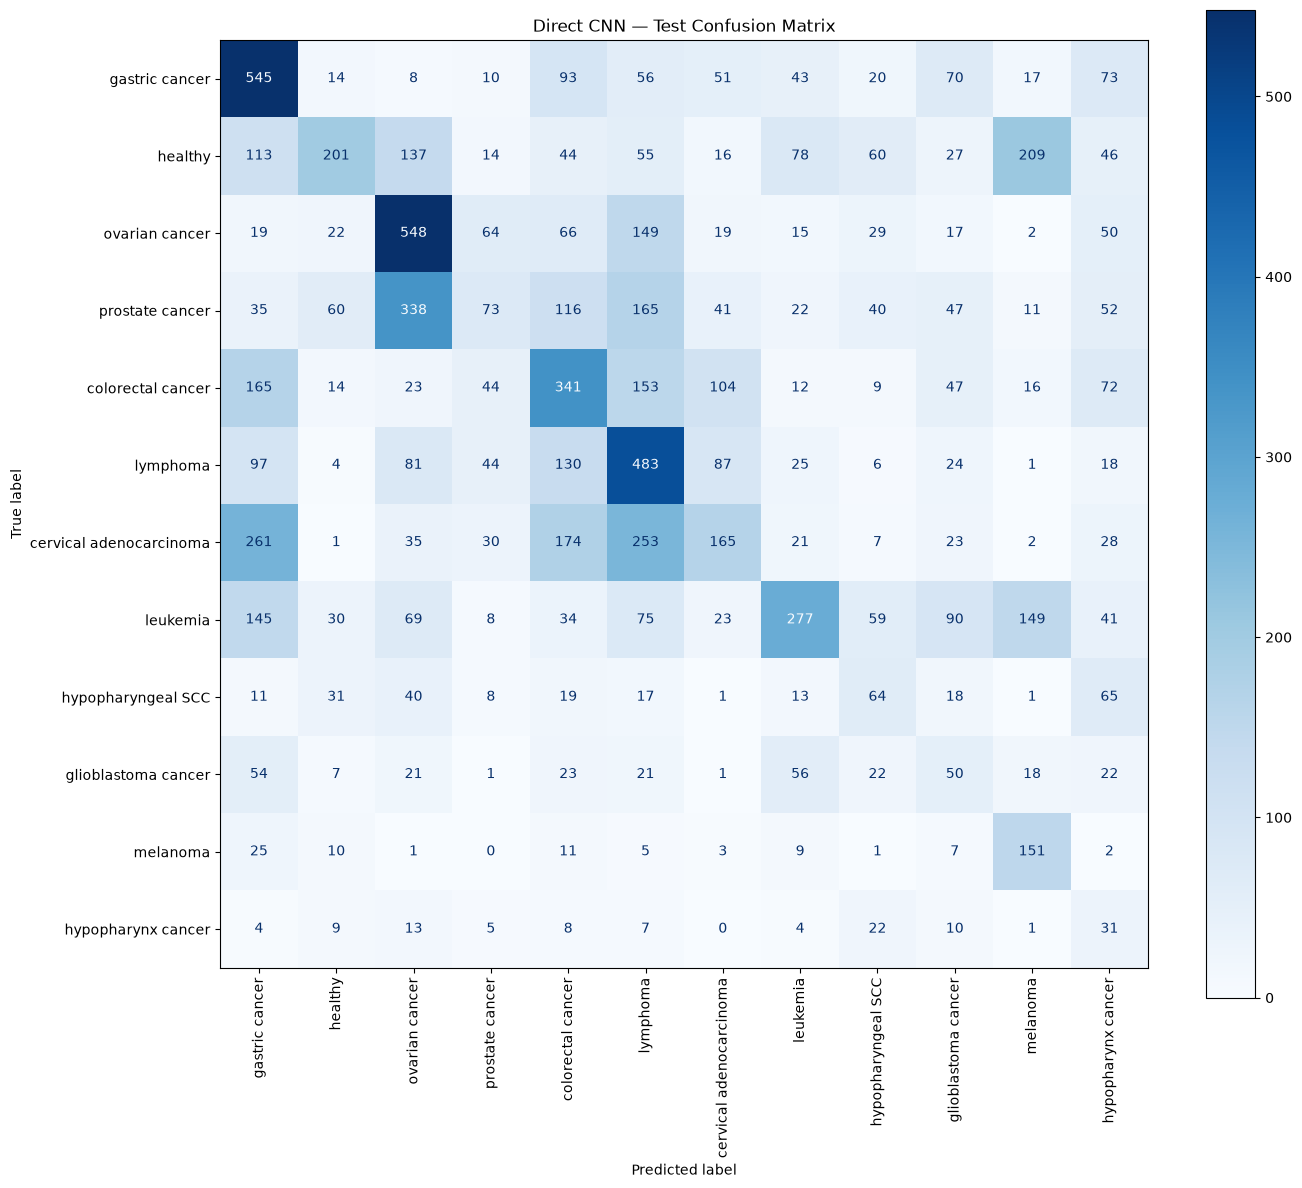

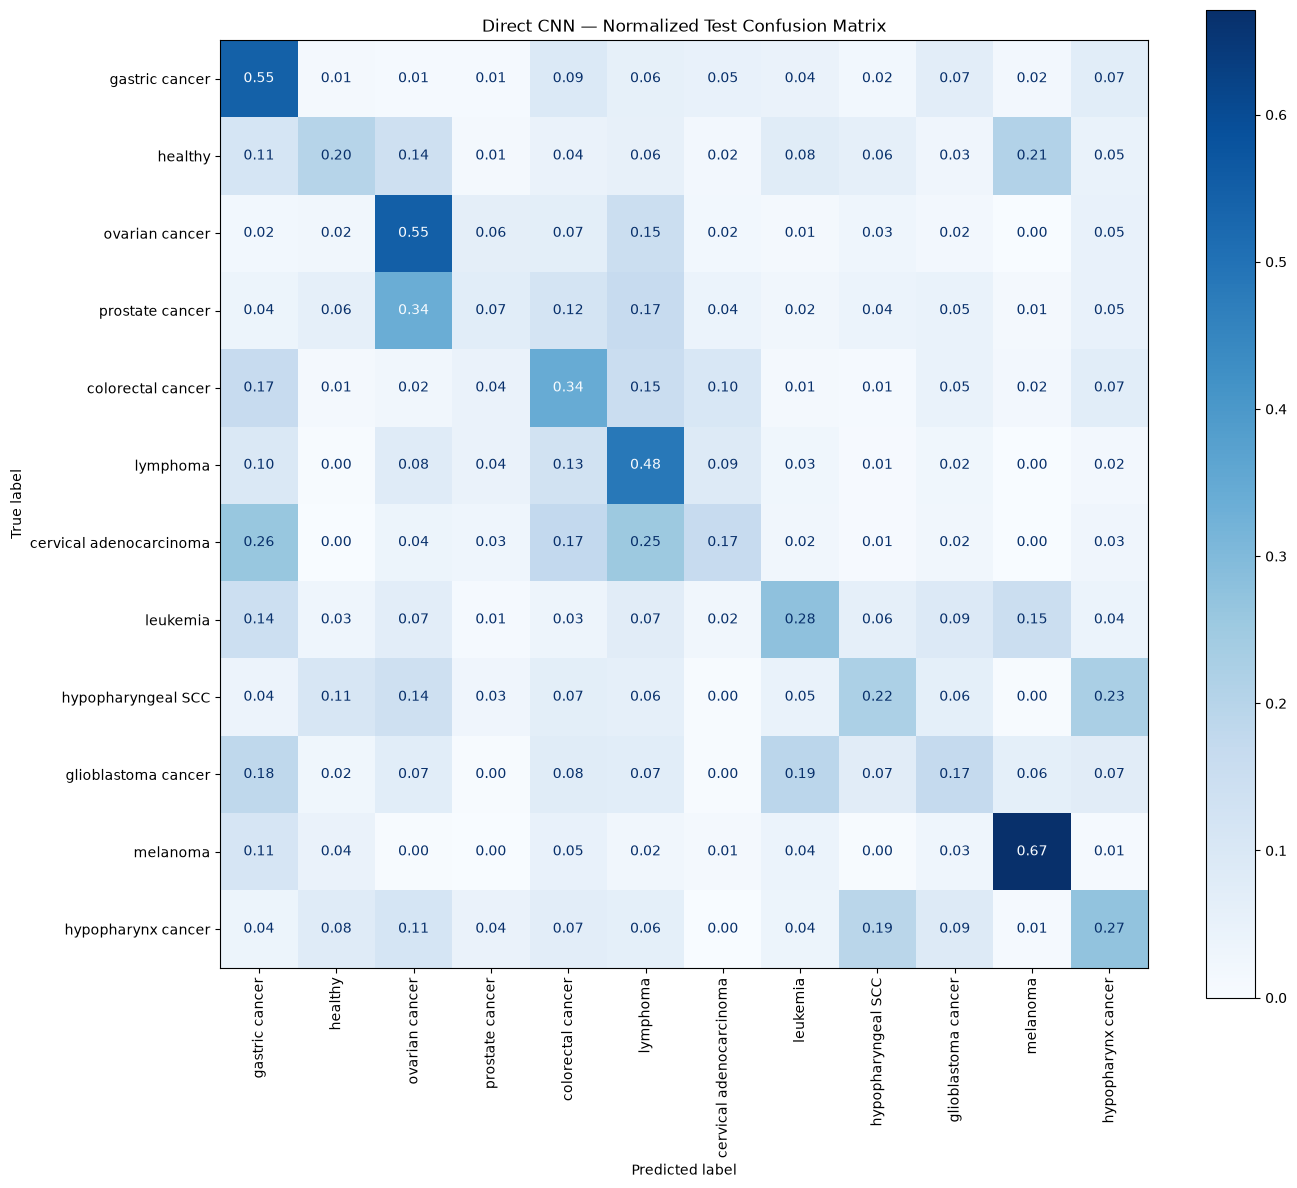

In [19]:
# ============================================================
# CELL 18 — DIRECT CNN FULL CONFUSION MATRICES
# ============================================================

labels_order = np.arange(
    N_CLASSES
)

display_names = [
    class_names[i]
    for i in labels_order
]


# ------------------------------------------------------------
# COUNTS
# ------------------------------------------------------------

cnn_cm_counts = confusion_matrix(
    test_labels,
    test_predictions,
    labels=labels_order
)


fig, ax = plt.subplots(
    figsize=(14, 12)
)

ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm_counts,
    display_labels=display_names
).plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    values_format="d"
)

ax.set_title(
    "Direct CNN — Test Confusion Matrix"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# NORMALIZED BY TRUE CLASS
# ------------------------------------------------------------

cnn_cm_normalized = confusion_matrix(
    test_labels,
    test_predictions,
    labels=labels_order,
    normalize="true"
)


fig, ax = plt.subplots(
    figsize=(14, 12)
)

ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm_normalized,
    display_labels=display_names
).plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    values_format=".2f"
)

ax.set_title(
    "Direct CNN — Normalized Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# CELL 19 — DIRECT CNN MAIN CLASS CONFUSIONS
# ============================================================

confusion_rows = []


for true_class in range(N_CLASSES):

    support = (
        cnn_cm_counts[
            true_class,
            :
        ].sum()
    )


    for predicted_class in range(
        N_CLASSES
    ):

        if (
            true_class
            == predicted_class
        ):
            continue


        count = int(
            cnn_cm_counts[
                true_class,
                predicted_class
            ]
        )


        if count == 0:
            continue


        confusion_rows.append(
            {
                "true_class_id":
                    true_class,

                "true_class":
                    class_names[
                        true_class
                    ],

                "predicted_class_id":
                    predicted_class,

                "predicted_class":
                    class_names[
                        predicted_class
                    ],

                "count":
                    count,

                "percentage_of_true_class":
                    count / support
            }
        )


cnn_confusions_df = (
    pd.DataFrame(
        confusion_rows
    )
    .sort_values(
        "percentage_of_true_class",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=" * 105)
print("DIRECT CNN — TOP CLASS CONFUSIONS")
print("=" * 105)

print(
    cnn_confusions_df
    .head(30)
    .to_string(
        index=False,
        formatters={
            "percentage_of_true_class":
                lambda x: f"{x:.2%}"
        }
    )
)

DIRECT CNN — TOP CLASS CONFUSIONS
 true_class_id              true_class  predicted_class_id         predicted_class  count percentage_of_true_class
             3         prostate cancer                   2          ovarian cancer    338                   33.80%
             6 cervical adenocarcinoma                   0          gastric cancer    261                   26.10%
             6 cervical adenocarcinoma                   5                lymphoma    253                   25.30%
             8      hypopharyngeal SCC                  11      hypopharynx cancer     65                   22.57%
             1                 healthy                  10                melanoma    209                   20.90%
            11      hypopharynx cancer                   8      hypopharyngeal SCC     22                   19.30%
             9     glioblastoma cancer                   7                leukemia     56                   18.92%
             9     glioblastoma cancer        

In [21]:
# ============================================================
# CELL 20 — FINAL DIRECT CNN SUMMARY + SAVE ARTIFACTS
# ============================================================

final_cnn_summary = pd.DataFrame(
    {
        "metric": [
            "train_samples",
            "best_epoch",

            "val_accuracy",
            "val_macro_f1",
            "val_balanced_accuracy",
            "val_top3",
            "val_top5",
            "val_balanced_top3",
            "val_balanced_top5",

            "test_accuracy",
            "test_macro_f1",
            "test_balanced_accuracy",
            "test_top3",
            "test_top5",
            "test_balanced_top3",
            "test_balanced_top5"
        ],

        "value": [
            len(train_metadata),
            best_checkpoint["epoch"],

            best_val["accuracy"],
            best_val["macro_f1"],
            best_val["balanced_accuracy"],
            best_val["top3"],
            best_val["top5"],
            best_val["balanced_top3"],
            best_val["balanced_top5"],

            test_metrics["accuracy"],
            test_metrics["macro_f1"],
            test_metrics["balanced_accuracy"],
            test_metrics["top3"],
            test_metrics["top5"],
            test_metrics["balanced_top3"],
            test_metrics["balanced_top5"]
        ]
    }
)


print("=" * 90)
print("DIRECT CNN — FINAL SUMMARY")
print("=" * 90)

print(
    final_cnn_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# SAVE TABLES
# ------------------------------------------------------------

final_cnn_summary.to_csv(
    ARTIFACTS_DIR
    / "direct_cnn_final_summary.csv",
    index=False
)

cnn_report_df.to_csv(
    ARTIFACTS_DIR
    / "direct_cnn_test_classification_report.csv"
)

cnn_confusions_df.to_csv(
    ARTIFACTS_DIR
    / "direct_cnn_test_confusions.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE EXACT FINAL TEST PREDICTIONS
# ------------------------------------------------------------

np.save(
    ARTIFACTS_DIR
    / "direct_cnn_test_labels.npy",
    test_labels
)

np.save(
    ARTIFACTS_DIR
    / "direct_cnn_test_predictions.npy",
    test_predictions
)

np.save(
    ARTIFACTS_DIR
    / "direct_cnn_test_logits.npy",
    test_logits
)


print()
print("Artifacts saved in:")
print(ARTIFACTS_DIR)

DIRECT CNN — FINAL SUMMARY
                metric        value
         train_samples 96167.000000
            best_epoch     3.000000
          val_accuracy     0.330052
          val_macro_f1     0.301661
 val_balanced_accuracy     0.334499
              val_top3     0.673536
              val_top5     0.836358
     val_balanced_top3     0.665092
     val_balanced_top5     0.827173
         test_accuracy     0.328253
         test_macro_f1     0.285780
test_balanced_accuracy     0.330599
             test_top3     0.675894
             test_top5     0.840861
    test_balanced_top3     0.669850
    test_balanced_top5     0.825723

Artifacts saved in:
D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\cnn_multiclass_fulltrain
